# **Importing Data**

In [2]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("atharvasoundankar/smart-farming-sensor-data-for-yield-prediction")

file_name = "Smart_Farming_Crop_Yield_2024.csv"
full_path = os.path.join(path, file_name)

df = pd.read_csv(full_path)

df.head()

ModuleNotFoundError: No module named 'kagglehub'

# **EDA: df.describe(), df.isnull().sum()**

In [ ]:
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.03014,26.586980,119.496000,4032.92694,22.442473,80.392248,0.602060
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.69167,13.202429,16.798046,1174.43304,7.283492,5.910664,0.175402
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.01000,5.050000,90.000000,2023.56000,10.004243,70.020021,0.300000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.66750,14.945000,105.750000,2994.82000,16.263202,75.374713,0.447500
50%,25.855000,6.530000,24.655000,191.545000,65.685000,6.99500,25.980000,119.000000,4071.69000,21.981743,80.650284,0.610000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.47000,38.005000,134.000000,5062.11000,28.528948,85.654629,0.750000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.00000,49.940000,150.000000,5998.29000,34.981531,89.991901,0.900000


In [ ]:
df.isnull().sum()

,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,150


# **Cleaning: handle missing, outliers, format datetime**

**Format Datetime**

In [ ]:
date_cols = ['timestamp', 'sowing_date', 'harvest_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_cols].dtypes

,0
timestamp,datetime64[ns]
sowing_date,datetime64[ns]
harvest_date,datetime64[ns]


**Handle Duplicate Data**

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

**Handle Missing Data**

In [ ]:
focus_cols = ['soil_moisture_%', 'temperature_C', 'humidity_%', 'soil_pH', 'yield_kg_per_hectare']

df[focus_cols].isnull().sum()

,0
soil_moisture_%,0
temperature_C,0
humidity_%,0
soil_pH,0
yield_kg_per_hectare,0


**Handle Outliers**

In [ ]:
for col in focus_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

df[focus_cols].describe()

,soil_moisture_%,temperature_C,humidity_%,soil_pH,yield_kg_per_hectare
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,26.750140,24.675740,65.194460,6.523980,4032.92694
std,10.150053,5.348899,14.642849,0.585558,1174.43304
min,10.160000,15.000000,40.230000,5.510000,2023.56000
25%,17.890000,20.295000,51.865000,6.030000,2994.82000
50%,25.855000,24.655000,65.685000,6.530000,4071.69000
75%,36.022500,29.090000,77.995000,7.040000,5062.11000
max,44.980000,34.840000,90.000000,7.500000,5998.29000


# **Analisis: Correlation Heatmap, Time Series Trend**

**Time Series (Tren Pergerakan Sensor)**

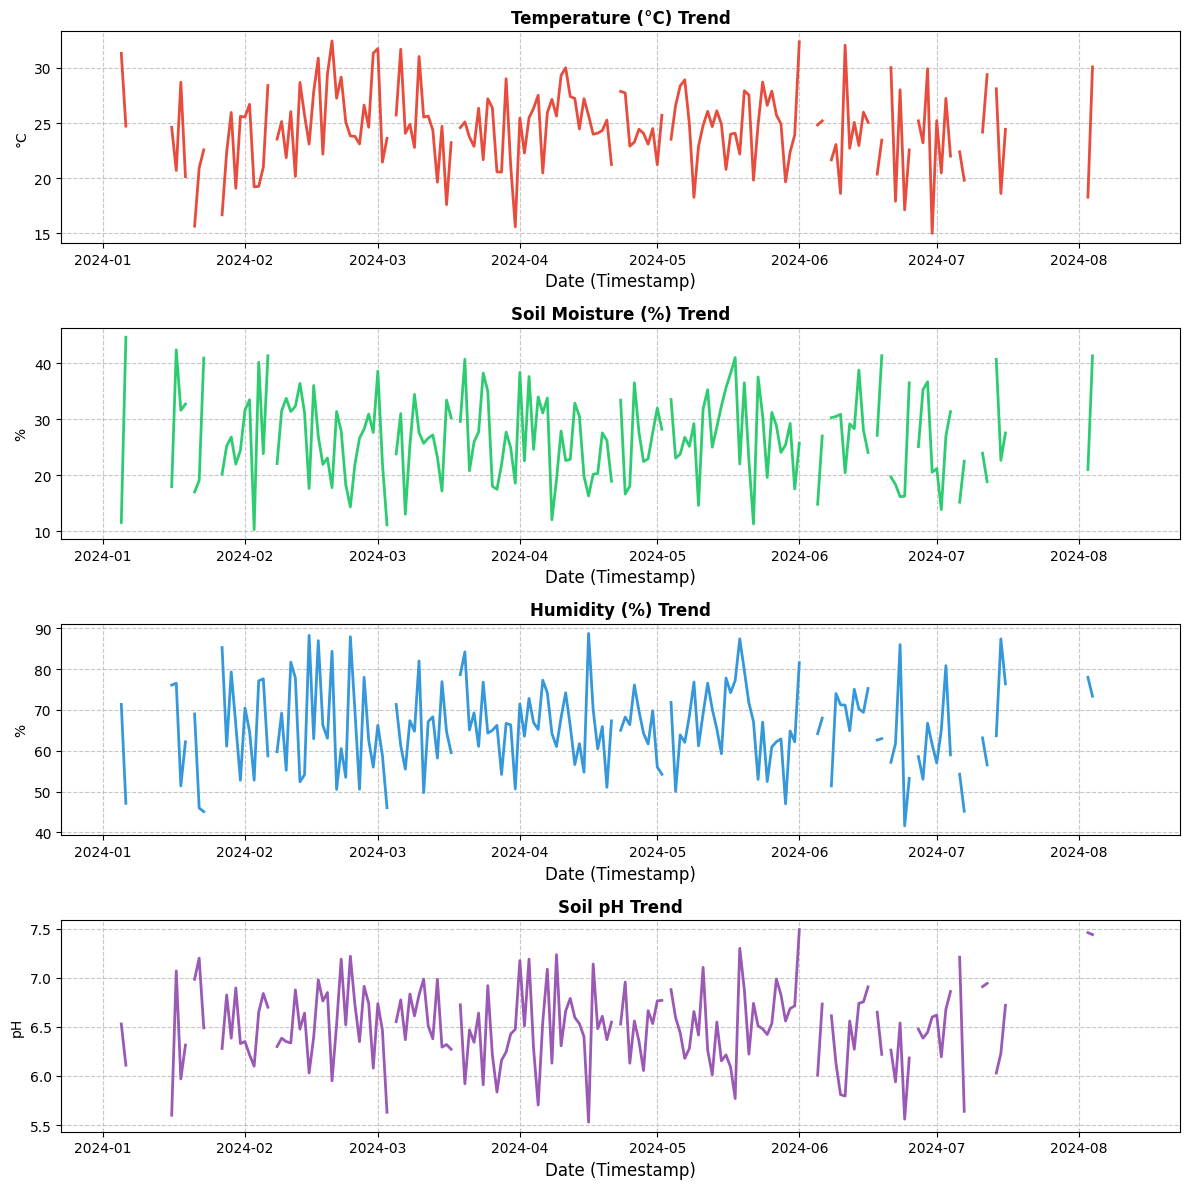

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_ts = df.copy()

df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
df_ts = df_ts.set_index('timestamp').sort_index()

daily_sensor = df_ts[['temperature_C', 'soil_moisture_%', 'humidity_%', 'soil_pH']].resample('D').mean()

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Temperature
axes[0].plot(daily_sensor.index, daily_sensor['temperature_C'], color='#e74c3c', linewidth=2)
axes[0].set_title('Temperature (°C) Trend', fontweight='bold', fontsize=12)
axes[0].set_ylabel('°C')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(labelbottom=True)
axes[0].set_xlabel('Date (Timestamp)', fontsize=12)

# Soil Moisture
axes[1].plot(daily_sensor.index, daily_sensor['soil_moisture_%'], color='#2ecc71', linewidth=2)
axes[1].set_title('Soil Moisture (%) Trend', fontweight='bold', fontsize=12)
axes[1].set_ylabel('%')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(labelbottom=True)
axes[1].set_xlabel('Date (Timestamp)', fontsize=12)

# Humidity
axes[2].plot(daily_sensor.index, daily_sensor['humidity_%'], color='#3498db', linewidth=2)
axes[2].set_title('Humidity (%) Trend', fontweight='bold', fontsize=12)
axes[2].set_ylabel('%')
axes[2].grid(True, linestyle='--', alpha=0.7)
axes[2].tick_params(labelbottom=True)
axes[2].set_xlabel('Date (Timestamp)', fontsize=12)

# Soil pH (Ungu)
axes[3].plot(daily_sensor.index, daily_sensor['soil_pH'], color='#9b59b6', linewidth=2)
axes[3].set_title('Soil pH Trend', fontweight='bold', fontsize=12)
axes[3].set_ylabel('pH')
axes[3].grid(True, linestyle='--', alpha=0.7)
axes[3].tick_params(labelbottom=True) # <-- Sudah kuperbaiki jadi axes[3]
axes[3].set_xlabel('Date (Timestamp)', fontsize=12)

plt.tight_layout()
plt.show()

**Gauge Meter (Kelembapan Tanah Saat Ini)**

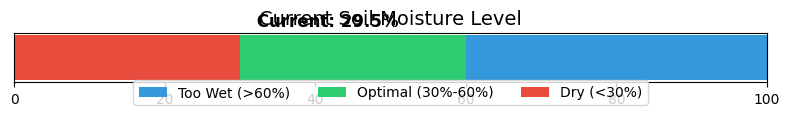

In [ ]:
import matplotlib.pyplot as plt

current_moisture = df_ts['soil_moisture_%'].tail(5).mean()

fig, ax = plt.subplots(figsize=(8, 2))

ax.barh([0], [100], color='#3498db', height=0.5, label='Too Wet (>60%)')
ax.barh([0], [60], color='#2ecc71', height=0.5, label='Optimal (30%-60%)')
ax.barh([0], [30], color='#e74c3c', height=0.5, label='Dry (<30%)')


ax.text(current_moisture + 2, 0.35, f' Current: {current_moisture:.1f}%', fontweight='bold', fontsize=12)

ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_title('Current Soil Moisture Level', fontsize=14)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.6), ncol=3)

plt.tight_layout()
plt.show()

**Heat Map (Korelasi Antar Sensor & Hasil Panen)**

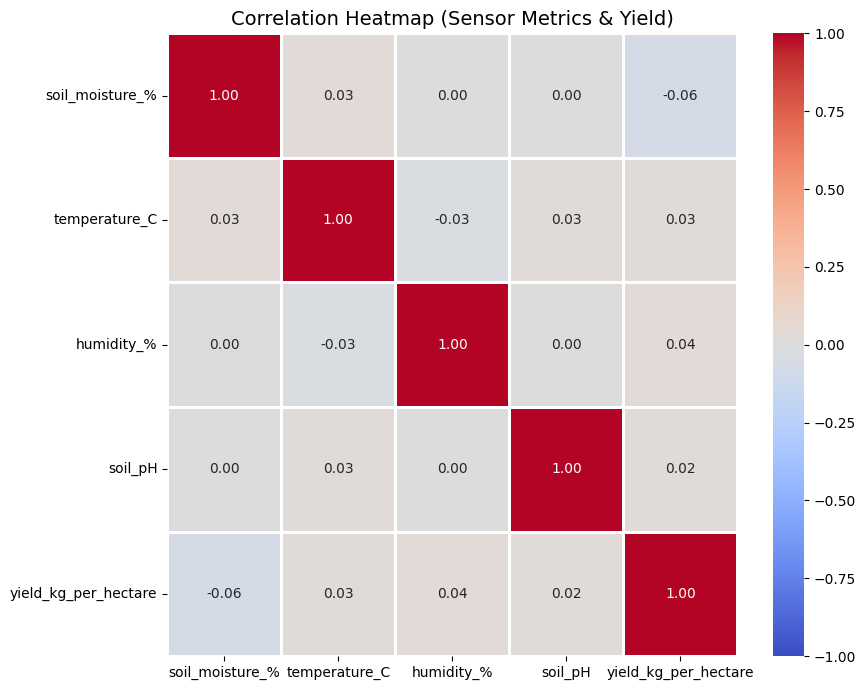

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[focus_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=1)

plt.title('Correlation Heatmap (Sensor Metrics & Yield)', fontsize=14)
plt.tight_layout()
plt.show()

**Alert System (Kotak Peringatan Warna Merah/Hijau)**

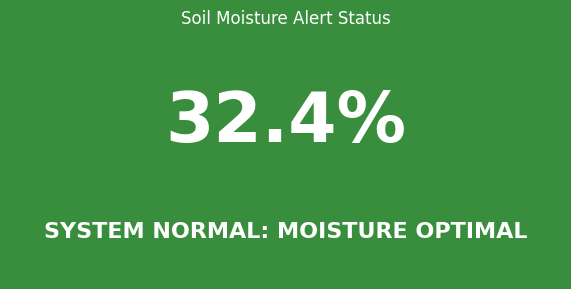

In [ ]:
import matplotlib.pyplot as plt

df_moisture = pd.read_csv(full_path)
current_moisture = df_moisture['soil_moisture_%'].dropna().tail(5).mean()

threshold = 20

if current_moisture < threshold:
    bg_color = '#d32f2f'
    text_alert = 'CRITICAL: IRRIGATION NEEDED!'
else:
    bg_color = '#388e3c'
    text_alert = 'SYSTEM NORMAL: MOISTURE OPTIMAL'

fig, ax = plt.subplots(figsize=(6, 3))

fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

ax.text(0.5, 0.65, f'{current_moisture:.1f}%', fontsize=50, color='white', ha='center', va='center', fontweight='bold')
ax.text(0.5, 0.2, text_alert, fontsize=16, color='white', ha='center', va='center', fontweight='bold')

ax.axis('off')
plt.title('Soil Moisture Alert Status', color='white', pad=10)

plt.tight_layout()
plt.show()

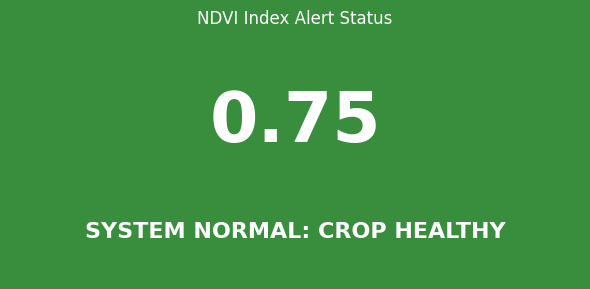

In [ ]:
import matplotlib.pyplot as plt

df_ndvi = pd.read_csv(full_path)
current_ndvi = df_ndvi['NDVI_index'].dropna().tail(5).mean()

threshold_ndvi = 0.3

if current_ndvi < threshold_ndvi:
    bg_color = '#d32f2f'
    text_alert = 'CRITICAL: POOR CROP HEALTH!'
else:
    bg_color = '#388e3c'
    text_alert = 'SYSTEM NORMAL: CROP HEALTHY'

fig, ax = plt.subplots(figsize=(6, 3))

fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

ax.text(0.5, 0.65, f'{current_ndvi:.2f}', fontsize=50, color='white', ha='center', va='center', fontweight='bold')
ax.text(0.5, 0.2, text_alert, fontsize=16, color='white', ha='center', va='center', fontweight='bold')

ax.axis('off')
plt.title('NDVI Index Alert Status', color='white', pad=10)

plt.tight_layout()
plt.show()

# **Data Quality Score (Before Cleaned)**

In [ ]:
import pandas as pd
from datetime import timedelta

total_cells = df.size
total_rows = len(df)
missing_values = df.isnull().sum().sum()
non_null_values = df.notnull().sum().sum()

# Accuracy
accuracy_score = 1 - (missing_values / total_cells)

# Completeness
completeness_score = non_null_values / total_cells

# Timeliness
latest_date = df['timestamp'].max()
thirty_days_ago = latest_date - timedelta(days=30)

recent_data_count = len(df[df['timestamp'] >= thirty_days_ago])
timeliness_score = (recent_data_count / total_rows) * 100

print("Data Quality Report:")
print(f"Accuracy Score     : {accuracy_score:.2%}")
print(f"Completeness Score : {completeness_score:.2%}")
print(f"Timeliness Score   : {timeliness_score:.2f}% (Data 30 hari terakhir)")

Data Quality Report:
Accuracy Score     : 97.45%
Completeness Score : 97.45%
Timeliness Score   : 1.40% (Data 30 hari terakhir)


# **Simpan**

In [ ]:
df['irrigation_type'] = df['irrigation_type'].fillna('Unknown')
df['crop_disease_status'] = df['crop_disease_status'].fillna('None')

df.to_csv('cleaned_data.csv', index=False)
print("Cleaned data saved to 'cleaned_data.csv'")

Cleaned data saved to 'cleaned_data.csv'


# **Data Quality Score (After Cleaned)**

In [ ]:
import pandas as pd
from datetime import timedelta

total_cells = df.size
total_rows = len(df)
missing_values = df.isnull().sum().sum()
non_null_values = df.notnull().sum().sum()

# Accuracy
accuracy_score = 1 - (missing_values / total_cells)

# Completeness
completeness_score = non_null_values / total_cells

# Timeliness
latest_date = df['timestamp'].max()
thirty_days_ago = latest_date - timedelta(days=30)

recent_data_count = len(df[df['timestamp'] >= thirty_days_ago])
timeliness_score = (recent_data_count / total_rows) * 100

print("Data Quality Report:")
print(f"Accuracy Score     : {accuracy_score:.2%}")
print(f"Completeness Score : {completeness_score:.2%}")
print(f"Timeliness Score   : {timeliness_score:.2f}% (Data 30 hari terakhir)")

Data Quality Report:
Accuracy Score     : 100.00%
Completeness Score : 100.00%
Timeliness Score   : 1.40% (Data 30 hari terakhir)
